# Exploratory Data Analysis (EDA) - Business Entity Resolution
This notebook contains a basic EDA to understand the dataset for the Business Entity Resolution challenge.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# File paths
s1_path = '../dataset/train/train_source1.tsv'
s2_path = '../dataset/train/train_source2.tsv'
s3_path = '../dataset/train/train_source3.tsv'
gt_path = '../dataset/train/train_ground_truth.tsv'


/home/rishang/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Load Data
Since the datasets are large (~5M rows for S2/S3), we'll read a sample for initial exploration.

In [2]:
# Load a sample of the data to avoid memory issues during initial EDA
sample_size = 100000
df_s1 = pd.read_csv(s1_path, sep='\t', nrows=sample_size)
df_s2 = pd.read_csv(s2_path, sep='\t', nrows=sample_size)
df_s3 = pd.read_csv(s3_path, sep='\t', nrows=sample_size)
df_gt = pd.read_csv(gt_path, sep='\t', nrows=sample_size)

print(f"Source 1 Sample Size: {len(df_s1)}")
print(f"Source 2 Sample Size: {len(df_s2)}")
print(f"Source 3 Sample Size: {len(df_s3)}")
display(df_s1.head())


Source 1 Sample Size: 100000
Source 2 Sample Size: 100000
Source 3 Sample Size: 100000


,entity_id,business_name,business_address,country
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US
3,S1-133037285,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",US
4,S1-755362802,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West ...",India


## 2. Missing Values
Check for missing business names and addresses.

In [3]:
print("Missing values in Source 1:")
print(df_s1.isnull().sum())

print("\nMissing values in Source 2:")
print(df_s2.isnull().sum())

print("\nMissing values in Source 3:")
print(df_s3.isnull().sum())


Missing values in Source 1:
entity_id           0
business_name       0
business_address    0
country             0
dtype: int64

Missing values in Source 2:
entity_id              0
business_name          0
business_address    3330
country                0
dtype: int64

Missing values in Source 3:
entity_id              0
business_name          0
business_address    3352
country                0
dtype: int64


## 3. Country Distribution
Let's check the distribution of countries across the sources.

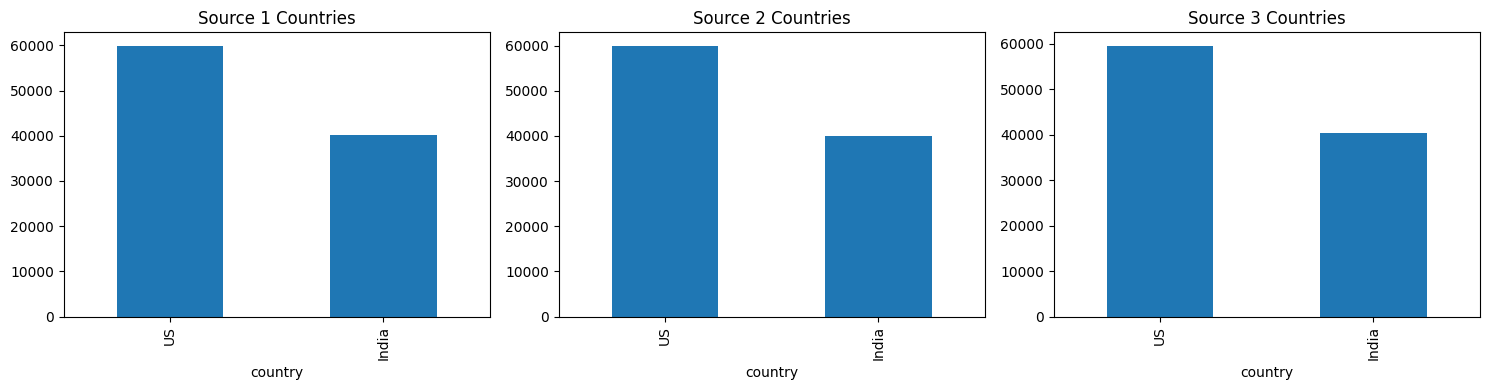

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_s1['country'].value_counts().plot(kind='bar', ax=axes[0], title='Source 1 Countries')
df_s2['country'].value_counts().plot(kind='bar', ax=axes[1], title='Source 2 Countries')
df_s3['country'].value_counts().plot(kind='bar', ax=axes[2], title='Source 3 Countries')

plt.tight_layout()
plt.show()


## 4. Ground Truth Analysis (Singletons & Cardinality)
Analyze how many matches each S1 entity has.

Match Count Summary:
count    100000.000000
mean          3.459970
std           1.701589
min           0.000000
25%           2.000000
50%           3.000000
75%           5.000000
max          11.000000
Name: match_count, dtype: float64

Number of Singletons (0 matches) in sample: 5594 (5.59%)


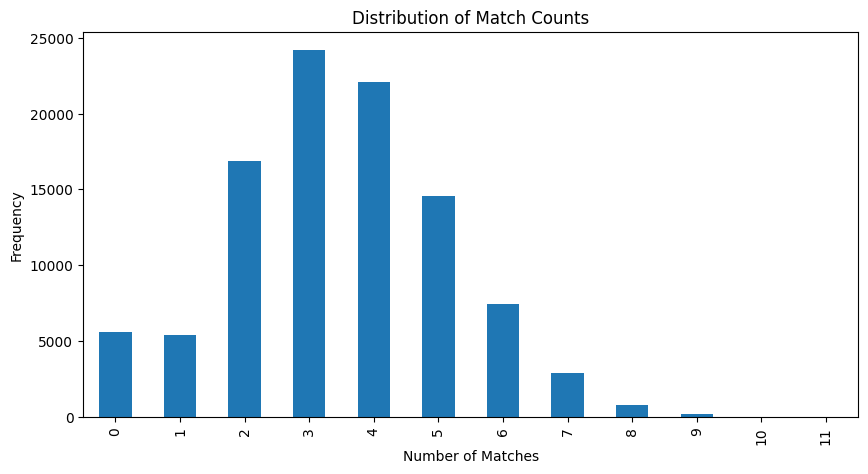

In [5]:
# Fill NaN with empty string for matches
df_gt['matched_entity_ids'] = df_gt['matched_entity_ids'].fillna('')

# Count number of matches (comma separated)
df_gt['match_count'] = df_gt['matched_entity_ids'].apply(lambda x: len(str(x).split(',')) if x != '' else 0)

print("Match Count Summary:")
print(df_gt['match_count'].describe())

singletons = (df_gt['match_count'] == 0).sum()
print(f"\nNumber of Singletons (0 matches) in sample: {singletons} ({(singletons/len(df_gt))*100:.2f}%)")

df_gt['match_count'].value_counts().sort_index().plot(kind='bar', figsize=(10, 5), title='Distribution of Match Counts')
plt.xlabel('Number of Matches')
plt.ylabel('Frequency')
plt.show()


## 5. Token Analysis & Address Variations
Analyze common words in names and addresses.

In [6]:
from collections import Counter
import re

def get_top_tokens(series, n=20):
    words = series.dropna().str.lower().apply(lambda x: re.findall(r'\b\w+\b', x)).sum()
    return Counter(words).most_common(n)

# This can be slow, so we just sample a small subset
print("Top Business Name tokens in Source 1 (sample):")
print(get_top_tokens(df_s1['business_name'].head(5000)))

print("\nTop Address tokens in Source 1 (sample):")
print(get_top_tokens(df_s1['business_address'].head(5000)))


Top Business Name tokens in Source 1 (sample):
[('limited', 1162), ('private', 949), ('llc', 828), ('inc', 536), ('ltd', 325), ('pvt', 271), ('care', 139), ('s', 135), ('and', 135), ('india', 122), ('c', 116), ('of', 111), ('l', 104), ('associates', 100), ('group', 92), ('center', 90), ('llp', 86), ('partners', 82), ('services', 73), ('global', 66)]

Top Address tokens in Source 1 (sample):
[('road', 1100), ('no', 998), ('delhi', 721), ('street', 685), ('drive', 481), ('unit', 454), ('avenue', 449), ('maharashtra', 439), ('nagar', 386), ('city', 347), ('floor', 345), ('west', 316), ('1', 306), ('mumbai', 301), ('tx', 292), ('lane', 265), ('pradesh', 260), ('new', 251), ('nc', 240), ('ny', 224)]
